First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset shape: (768, 9)

Without Feature Scaling
----------------------------------------
Accuracy : 0.7468
Precision: 0.6379
Recall   : 0.6727
F1-score : 0.6549

With Feature Scaling
----------------------------------------
Accuracy : 0.7532
Precision: 0.6491
Recall   : 0.6727
F1-score 

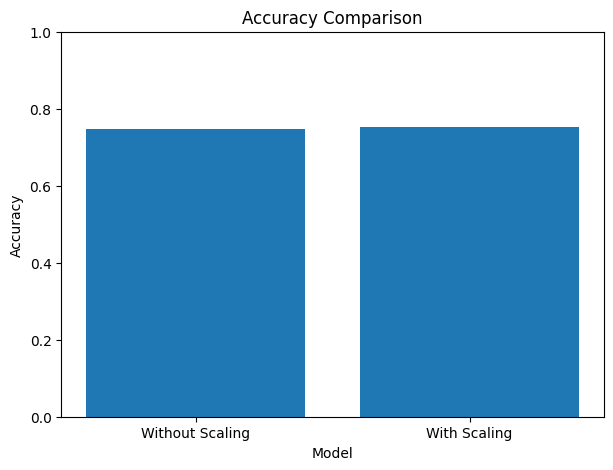

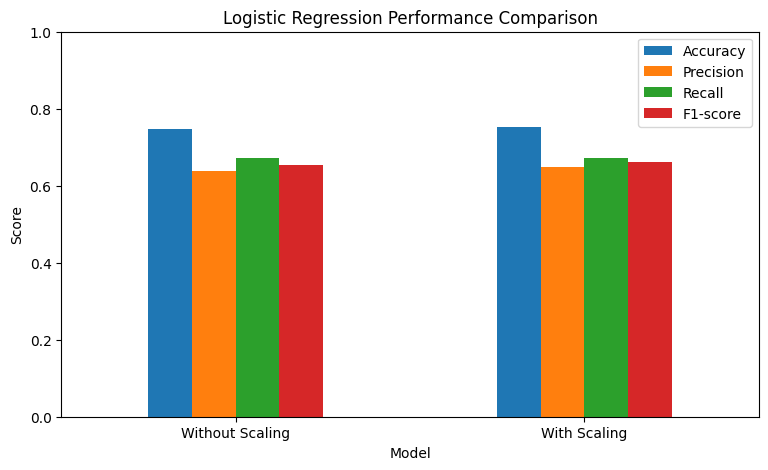

In [5]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

data = pd.read_csv(url, names=columns)

print("First 5 rows:")
print(data.head())

print("\nDataset shape:", data.shape)
#preprocesssing
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# 3. FUNCTION TO EVALUATE MODEL

def evaluate_model(y_test, y_pred, model_name):

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("\n" + model_name)
    print("-" * 40)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")


    return [accuracy, precision, recall, f1]

# 4. LOGISTIC REGRESSION WITHOUT FEATURE SCALING

model_without_scaling = LogisticRegression(max_iter=1000)

model_without_scaling.fit(X_train, y_train)

y_pred_without_scaling = model_without_scaling.predict(X_test)

results_without_scaling = evaluate_model(
    y_test,
    y_pred_without_scaling,
    "Without Feature Scaling"
)

# 5. FEATURE SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. LOGISTIC REGRESSION WITH FEATURE SCALING

model_with_scaling = LogisticRegression(max_iter=1000)

model_with_scaling.fit(X_train_scaled, y_train)

y_pred_with_scaling = model_with_scaling.predict(X_test_scaled)

results_with_scaling = evaluate_model(
    y_test,
    y_pred_with_scaling,
    "With Feature Scaling"
)

# 7. PERFORMANCE COMPARISON TABLE

comparison = pd.DataFrame(
    {
        "Without Scaling": results_without_scaling,
        "With Scaling": results_with_scaling
    },
    index=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

print("\n" + "=" * 60)
print("PERFORMANCE COMPARISON")
print("=" * 60)

print(comparison.round(4))

# 8. ACCURACY COMPARISON GRAPH

plt.figure(figsize=(7, 5))

models = ["Without Scaling", "With Scaling"]
accuracy_values = [
    results_without_scaling[0],
    results_with_scaling[0]
]

plt.bar(models, accuracy_values)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.ylim(0, 1)

plt.show()

# 9. ALL METRICS COMPARISON GRAPH
comparison.T.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Logistic Regression Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()